# 02 — Motif Detection

Search for recurring structural patterns in ZX diagrams using
hand-crafted motifs, bottom-up enumeration, and neighborhood extraction.

In [1]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
from collections import Counter

from zx_motifs.algorithms.registry import REGISTRY
from zx_motifs.pipeline.converter import convert_at_all_levels
from zx_motifs.pipeline.featurizer import pyzx_to_networkx
from zx_motifs.pipeline.matcher import find_motif_across_corpus
from zx_motifs.pipeline.motif_generators import (
    HANDCRAFTED_MOTIFS,
    find_recurring_subgraphs,
)

## Build the Corpus

Convert all algorithms and build the NetworkX graph corpus.

In [2]:
all_snapshots = []
for entry in REGISTRY:
    min_q, max_q = entry.qubit_range
    for n in range(min_q, min(max_q + 1, 6)):
        try:
            qc = entry.generator(n_qubits=n)
            snaps = convert_at_all_levels(qc, f"{entry.name}_q{n}")
            all_snapshots.extend(snaps)
        except Exception as e:
            print(f"  {entry.name} (n={n}): FAILED — {e}")

nx_graphs = {}
for snap in all_snapshots:
    nxg = pyzx_to_networkx(snap.graph, coarsen_phases=True)
    nx_graphs[(snap.algorithm_name, snap.level.value)] = nxg

print(f"Corpus: {len(nx_graphs)} graphs")

Corpus: 402 graphs


## Hand-Crafted Motif Scan

In [3]:
print("=== Hand-Crafted Motif Scan ===\n")
for motif in HANDCRAFTED_MOTIFS:
    find_motif_across_corpus(motif, nx_graphs, target_level="spider_fused")

    algos_found = set(m.host_algorithm for m in motif.occurrences)
    print(f"  {motif.motif_id}: {len(motif.occurrences)} matches "
          f"across {len(algos_found)} algorithms")
    if algos_found:
        print(f"    Found in: {sorted(algos_found)[:5]}...")

=== Hand-Crafted Motif Scan ===

  phase_gadget_2t: 0 matches across 0 algorithms
  phase_gadget_3t: 0 matches across 0 algorithms
  cx_pair: 453 matches across 58 algorithms
    Found in: ['bell_state_q2', 'bell_state_q3', 'bell_state_q4', 'bell_state_q5', 'bernstein_vazirani_q3']...
  hadamard_sandwich: 20 matches across 4 algorithms
    Found in: ['trotter_heisenberg_q2', 'trotter_heisenberg_q3', 'trotter_heisenberg_q4', 'trotter_heisenberg_q5']...
  zz_interaction: 0 matches across 0 algorithms
  syndrome_extraction: 554 matches across 43 algorithms
    Found in: ['bell_state_q3', 'bell_state_q4', 'bell_state_q5', 'bit_flip_code_q5', 'data_reuploading_q3']...
  toffoli_core: 0 matches across 0 algorithms
  cluster_chain: 26 matches across 7 algorithms
    Found in: ['cluster_state_q3', 'cluster_state_q4', 'cluster_state_q5', 'hw_efficient_ansatz_q3', 'hw_efficient_ansatz_q4']...
  trotter_layer: 0 matches across 0 algorithms


## Bottom-Up Discovery

In [4]:
auto_motifs = find_recurring_subgraphs(
    nx_graphs,
    target_level="spider_fused",
    min_size=3,
    max_size=5,
    min_algorithms=2,
)

print(f"\n=== Auto-Discovered Motifs: {len(auto_motifs)} ===\n")
for motif in auto_motifs[:10]:
    find_motif_across_corpus(motif, nx_graphs, target_level="spider_fused")
    algos = set(m.host_algorithm for m in motif.occurrences)
    node_types = [d.get("vertex_type") for _, d in motif.graph.nodes(data=True)]
    print(f"  {motif.motif_id}: {Counter(node_types)}, "
          f"{motif.graph.number_of_edges()} edges, "
          f"in {len(algos)} algos")


=== Auto-Discovered Motifs: 45 ===

  auto_3fc445cf586b: Counter({'X': 2, 'Z': 1}), 2 edges, in 43 algos
  auto_6dff4e1a05c7: Counter({'Z': 2, 'X': 1}), 2 edges, in 25 algos
  auto_5eb7a0e35e67: Counter({'Z': 2, 'X': 1}), 2 edges, in 43 algos
  auto_043e9a19c6e4: Counter({'X': 2, 'Z': 1}), 2 edges, in 14 algos
  auto_733c058312df: Counter({'Z': 2, 'X': 1}), 2 edges, in 20 algos
  auto_abf09bd4fde1: Counter({'X': 2, 'Z': 1}), 2 edges, in 22 algos
  auto_8290b830463d: Counter({'X': 2, 'Z': 1}), 2 edges, in 14 algos
  auto_0b865eadd90b: Counter({'X': 3, 'Z': 1}), 3 edges, in 25 algos
  auto_f61a327a9c8c: Counter({'X': 3, 'Z': 1}), 3 edges, in 7 algos
  auto_1280c646ede5: Counter({'X': 2, 'Z': 1}), 2 edges, in 10 algos


## Top Motif Visualization

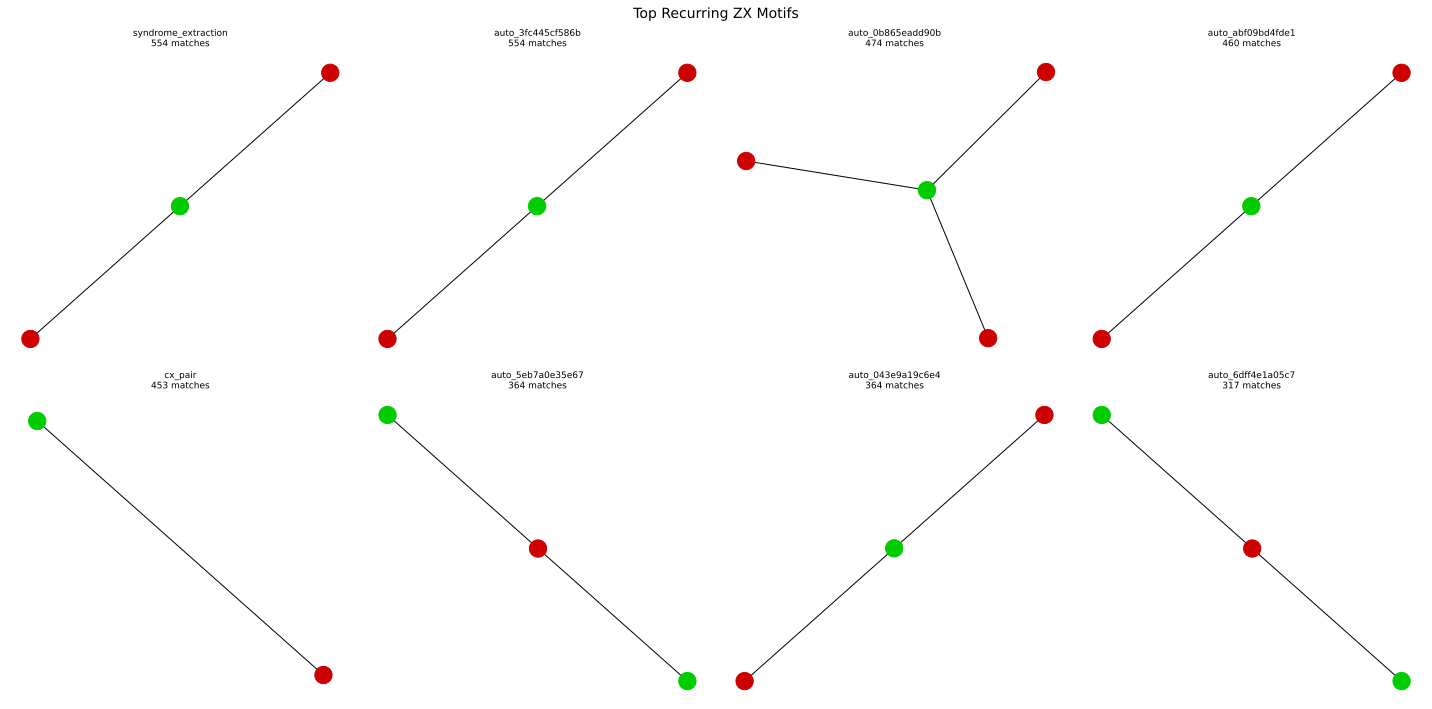

In [5]:
all_motifs = HANDCRAFTED_MOTIFS + auto_motifs
all_motifs.sort(key=lambda m: len(m.occurrences), reverse=True)

n_display = min(8, len(all_motifs))
cols = min(4, n_display)
rows = (n_display + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 5 * rows))
if n_display == 1:
    axes = [axes]
else:
    axes = list(axes.flat) if hasattr(axes, 'flat') else [axes]

color_map = {"Z": "#00cc00", "X": "#cc0000", "H_BOX": "#cccc00", "BOUNDARY": "#888888"}

for ax, motif in zip(axes[:n_display], all_motifs[:n_display]):
    pos = nx.spring_layout(motif.graph, seed=42)
    colors = [color_map.get(motif.graph.nodes[n].get("vertex_type", "?"), "#0000cc")
              for n in motif.graph.nodes()]

    for u, v, d in motif.graph.edges(data=True):
        style = "dashed" if d.get("edge_type") == "HADAMARD" else "solid"
        nx.draw_networkx_edges(motif.graph, pos, edgelist=[(u, v)], style=style, ax=ax)

    nx.draw_networkx_nodes(motif.graph, pos, node_color=colors, node_size=300, ax=ax)
    ax.set_title(f"{motif.motif_id}\n{len(motif.occurrences)} matches", fontsize=9)
    ax.axis("off")

# Hide unused axes
for ax in axes[n_display:]:
    ax.set_visible(False)

plt.suptitle("Top Recurring ZX Motifs", fontsize=14)
plt.tight_layout()
plt.savefig("top_motifs.png", dpi=150)
plt.show()

## Cross-Algorithm Heatmap

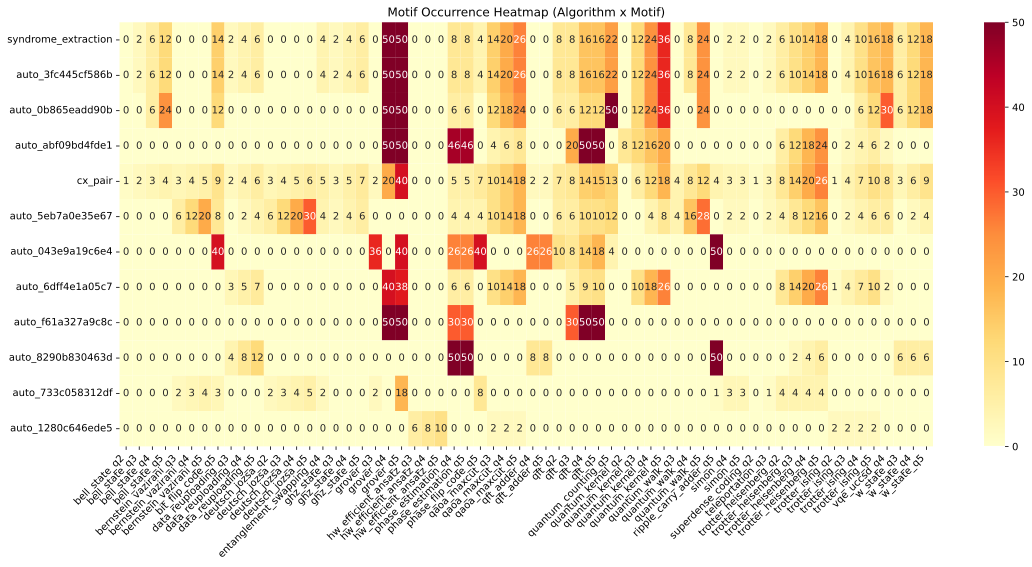

In [6]:
try:
    import seaborn as sns

    top_motifs = [m for m in all_motifs[:12] if m.occurrences]
    if top_motifs:
        algo_names = sorted(set(
            m.host_algorithm for motif in top_motifs for m in motif.occurrences
        ))

        heatmap_data = np.zeros((len(top_motifs), len(algo_names)))
        for i, motif in enumerate(top_motifs):
            algo_counts = Counter(m.host_algorithm for m in motif.occurrences)
            for j, algo in enumerate(algo_names):
                heatmap_data[i, j] = algo_counts.get(algo, 0)

        fig, ax = plt.subplots(figsize=(16, 8))
        sns.heatmap(
            heatmap_data, annot=True, fmt=".0f",
            xticklabels=algo_names,
            yticklabels=[m.motif_id for m in top_motifs],
            cmap="YlOrRd", ax=ax,
        )
        plt.title("Motif Occurrence Heatmap (Algorithm x Motif)")
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        plt.savefig("motif_heatmap.png", dpi=150)
        plt.show()
    else:
        print("No motifs with occurrences to display.")
except ImportError:
    print("Install seaborn for heatmap: pip install seaborn")